# 盲去卷积：Unnatural L0 稀疏表示（Xu et al., CVPR 2013）

包导入，matplotlib中文支持

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

# matplotlib 中文支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)


## 输入与观测

- 输入图片：mana.jpg（RGB → 灰度，归一化到 [0,1]）
- 卷积核：运动模糊核（长度 25、角度 30°）
- 观测：`observed = blur ⊛ kernel + noise`，高斯白噪声 σ=0.005
- 目标：盲去卷积恢复原图（不知道核的具体形状）

In [2]:
def motion_blur_kernel(length, angle_deg):
    """生成运动模糊核：沿角度方向的倾斜线段，归一化后和为 1"""
    angle = np.deg2rad(angle_deg)
    t = np.linspace(-(length // 2), length // 2, length)
    kx = np.round(t * np.cos(angle)).astype(int)
    ky = np.round(t * np.sin(angle)).astype(int)
    kx -= kx.min()
    ky -= ky.min()
    kernel = np.zeros((ky.max() + 1, kx.max() + 1))
    kernel[ky, kx] = 1.0
    return kernel / kernel.sum()


图像尺寸: (553, 526)  像素范围: [0.000, 1.000]
真值核尺寸: (13, 21)


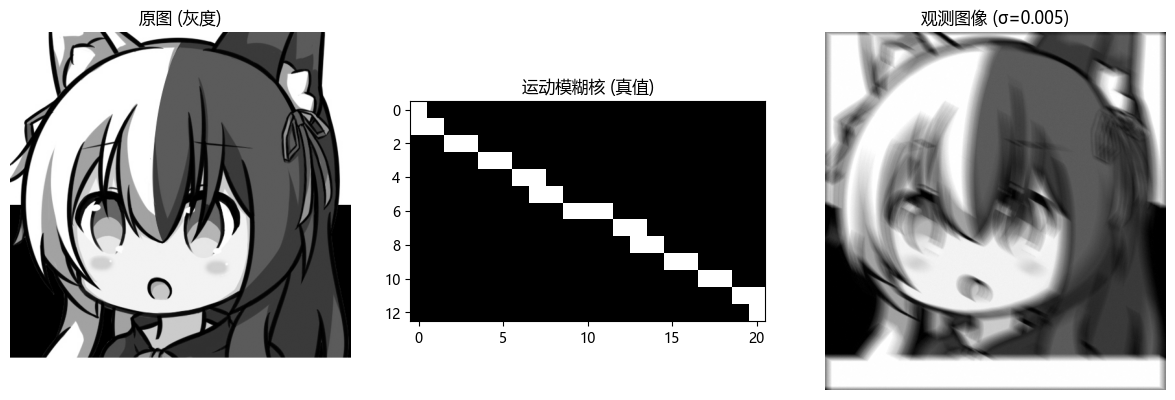

In [3]:
# 读取图片（RGB → 灰度），注意 imread 返回 [0,255] 需归一化
rgb = plt.imread('mana.jpg')
if rgb.max() > 1.0:
    rgb = rgb / 255.0
gray = rgb.mean(axis=2)
print(f'图像尺寸: {gray.shape}  像素范围: [{gray.min():.3f}, {gray.max():.3f}]')

# 运动模糊核（真值，仅用于生成观测；盲去卷积时未知）
kernel_true = motion_blur_kernel(length=25, angle_deg=30)
print(f'真值核尺寸: {kernel_true.shape}')

# 模糊 + 高斯噪声 → 观测图像
blurred = fftconvolve(gray, kernel_true, mode='same')
noise_sigma = 0.005
observed = np.clip(blurred + np.random.normal(0, noise_sigma, gray.shape), 0, 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(gray, cmap='gray'); plt.title('原图 (灰度)'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(kernel_true, cmap='gray'); plt.title('运动模糊核 (真值)')
plt.subplot(1, 3, 3); plt.imshow(observed, cmap='gray'); plt.title(f'观测图像 (σ={noise_sigma})'); plt.axis('off')
plt.tight_layout(); plt.show()


## 算法：Unnatural L0 稀疏表示去模糊（Xu et al., CVPR 2013）

参考实现：`ref_repos/Unnatural-L0-Reproducing`（MATLAB 代码忠实移植）

**核心思想**：用**梯度的 L0 范数**（统计非零梯度个数）作为稀疏先验，
比 L1/L2 更能保留锐利边缘、抑制振铃：

$$\min_{k, im} \; \| k \circledast im - y \|_2^2 + \lambda\, C(im) + \gamma\, \|k\|_2^2$$

其中 $C(im)$ 统计 $\nabla im$ 中非零梯度的个数（L0 稀疏惩罚），
用**半二次分裂**（引入辅助梯度变量 + ε 延续）迭代求解。

> 说明：参考实现 README 指出，对较大的模糊、真实图像边界等情况
> 效果可能不理想，属已知局限；本笔记本忠实还原参考代码。

In [4]:
def psf2otf(psf, outsize):
    """MATLAB psf2otf：把核中心移到原点后补零到 outsize，再 FFT

    频域乘法对应的空间域核必须以 (0,0) 为原点，否则相位错误。
    """
    psf_size = np.array(psf.shape)
    outsize = np.array(outsize)
    pad = outsize - psf_size
    psf = np.pad(psf, ((0, int(pad[0])), (0, int(pad[1]))), mode='constant')
    shifts = -np.floor(psf_size / 2).astype(int)
    psf = np.roll(psf, (int(shifts[0]), int(shifts[1])), axis=(0, 1))
    return np.fft.fft2(psf)


In [5]:
def otf2psf(otf, psf_size):
    """MATLAB otf2psf：ifft 后循环移位、裁剪到 psf_size"""
    psf = np.real(np.fft.ifft2(otf))
    shifts = np.floor(np.array(psf_size) / 2).astype(int)
    psf = np.roll(psf, (int(shifts[0]), int(shifts[1])), axis=(0, 1))
    return psf[:psf_size[0], :psf_size[1]]


### 第二步：L0 核估计（交替更新，参考 uniform_deblur.m）

- **图像更新**（`update_sub_image`）：固定核，用 L0 稀疏先验估计清晰图像
  （半二次分裂：辅助梯度变量 h、v，ε 从 0.1 逐级减半延续）
- **核更新**（`update_kernel_uniform`）：固定图像，FFT 域最小二乘估计核
- 两者交替 5 轮；核初值取参考风格的随机小块（25×25 支持域）

In [6]:
def update_sub_image(im, Fy, FK, lam):
    """L0 稀疏梯度先验的图像更新（半二次分裂 + ε 延续，参考 update_sub_image.m）

    固定核 FK：min_im ||k⊛im - y||² + λ·C(im)，C 统计非零梯度个数。
    h、v 为辅助梯度变量，阈值 (h²+v²) < ε² 判定置零（L0 硬阈值），
    ε 从 0.1 逐级减半延续，内层迭代次数随 ε 增加。
    """
    m, n = Fy.shape
    fx = np.array([[1.], [-1.]])
    fy = np.array([[1., -1.]])
    partial_h = psf2otf(fx, (m, n))
    partial_v = psf2otf(fy, (m, n))
    FD = np.conj(partial_h) * partial_h + np.conj(partial_v) * partial_v
    conjFK_FK = np.conj(FK) * FK
    conjFK_Fy = np.conj(FK) * Fy
    eps = 0.1
    for _ in range(4):
        const = lam / eps ** 2
        mat2 = conjFK_FK + const * FD
        for _ in range(int(round(0.1 / eps))):
            # 环绕差分梯度（对应 MATLAB diff + 首尾差）
            h = np.vstack([np.diff(im, axis=0), (im[0, :] - im[-1, :])[None, :]])
            v = np.hstack([np.diff(im, axis=1), (im[:, 0] - im[:, -1])[:, None]])
            # L0 硬阈值：梯度平方和小于 ε² 则置零
            t = (h ** 2 + v ** 2) < eps ** 2
            h[t] = 0.0
            v[t] = 0.0
            Fh = np.fft.fft2(h)
            Fv = np.fft.fft2(v)
            mat1 = conjFK_Fy + const * (np.conj(partial_h) * Fh + np.conj(partial_v) * Fv)
            Fim = mat1 / mat2
            im = np.real(np.fft.ifft2(Fim))
        eps = eps / 2
    return im


In [7]:
def update_kernel_uniform(Fy, Fim, gamma, size_k):
    """核更新：FFT 域最小二乘（参考 update_kernel_uniform.m）

    FK = conj(Fim)·Fy / (|Fim|² + gamma)，再经 otf2psf 转回空间域
    """
    mat1 = np.conj(Fim) * Fy
    mat2 = np.conj(Fim) * Fim
    FK = mat1 / (mat2 + gamma)
    k = otf2psf(FK, size_k)
    FK = psf2otf(k, Fy.shape)
    return k, FK


In [8]:
def uniform_deblur(y, lam, gamma, init_k, iters=5):
    """核估计主循环（参考 uniform_deblur.m）：交替图像更新与核更新

    参数
    ----
    y : 模糊图像
    lam : L0 稀疏先验强度（图像更新用）
    gamma : 核正则强度（核更新用）
    init_k : 核初值
    iters : 交替轮数

    返回
    ----
    k : 估计核
    FK : 估计核的频域表示（供非盲反卷积使用）
    """
    m, n = y.shape
    Fy = np.fft.fft2(y)
    k = init_k.copy()
    FK = psf2otf(k, (m, n))
    im = y.copy()
    for _ in range(iters):
        im = update_sub_image(im, Fy, FK, lam)
        Fim = np.fft.fft2(im)
        k, FK = update_kernel_uniform(Fy, Fim, gamma, k.shape)
    return k, FK


估计核尺寸: (25, 25)


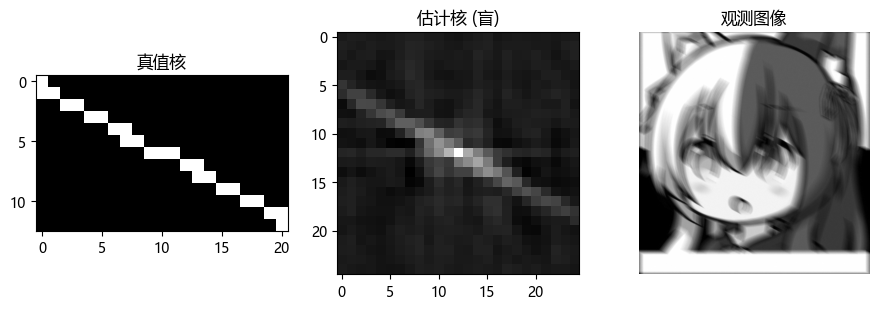

In [9]:
# 核初值：参考风格（25×25 支持域，中心 5×5 随机小块，归一化）
init_k = np.zeros((25, 25))
init_k[10:15, 10:15] = np.random.rand(5, 5)
init_k = init_k / init_k.sum()

# 运行 L0 核估计（全图，参考实现参数 lam=0.01, gamma=40, 5 轮交替）
k_est, FK = uniform_deblur(observed, lam=0.01, gamma=40, init_k=init_k, iters=5)
print(f'估计核尺寸: {k_est.shape}')

plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1); plt.imshow(kernel_true, cmap='gray'); plt.title('真值核')
plt.subplot(1, 3, 2); plt.imshow(k_est, cmap='gray'); plt.title('估计核 (盲)')
plt.subplot(1, 3, 3); plt.imshow(observed, cmap='gray'); plt.title('观测图像'); plt.axis('off')
plt.tight_layout(); plt.show()


### 第三步：非盲反卷积重建清晰图像 L（参考 deconv.m）

- 核已由第二步估计得到（固定不再更新）
- 用 **L1 稀疏先验**（软阈值收缩）的半二次分裂算法重建清晰图像
- 参考实现说明：该版本为 L1 正则版，对较大模糊效果有限属已知局限

In [10]:
def deconv(im, Fy, FK, lam):
    """非盲反卷积（L1 稀疏先验，软阈值收缩，参考 deconv.m）

    半二次分裂：ε 从 1 逐级减半延续，内层对辅助梯度 h、v
    做 L1 软阈值（阈值 = lam/ε²），再 FFT 域求解。
    """
    m, n = Fy.shape
    fx = np.array([[1.], [-1.]])
    fy = np.array([[1., -1.]])
    partial_h = psf2otf(fx, (m, n))
    partial_v = psf2otf(fy, (m, n))
    FD = np.conj(partial_h) * partial_h + np.conj(partial_v) * partial_v
    eps = 1.0
    conjFK_FK = np.conj(FK) * FK
    conjFK_Fy = np.conj(FK) * Fy
    for _ in range(4):
        const = lam / eps ** 2
        mat2 = conjFK_FK + const * FD
        for _ in range(int(round(2.0 / eps))):
            # 环绕差分梯度
            h = np.vstack([np.diff(im, axis=0), (im[0, :] - im[-1, :])[None, :]])
            v = np.hstack([np.diff(im, axis=1), (im[:, 0] - im[:, -1])[:, None]])
            # L1 软阈值收缩（对应 MATLAB 的分段软阈值）
            beta = eps ** 2
            thr = lam / beta
            h = np.sign(h) * np.maximum(np.abs(h) - thr, 0.0)
            v = np.sign(v) * np.maximum(np.abs(v) - thr, 0.0)
            Fh = np.fft.fft2(h)
            Fv = np.fft.fft2(v)
            mat1 = conjFK_Fy + const * (np.conj(partial_h) * Fh + np.conj(partial_v) * Fv)
            Fim = mat1 / mat2
            im = np.real(np.fft.ifft2(Fim))
        eps = eps / 2
    return im


In [11]:
# 执行第三步：用估计核做非盲反卷积，重建清晰图像 L
Fy = np.fft.fft2(observed)
L = np.clip(deconv(observed, Fy, FK, lam=1e-3), 0, 1)
print(f'重建完成: {L.shape}')


重建完成: (553, 526)


### 结果评估（PSNR / SSIM）

In [12]:
def compute_psnr(img, ref, data_range=1.0):
    """峰值信噪比 PSNR（dB）"""
    mse = np.mean((img - ref) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(data_range ** 2 / mse)


In [13]:
def compute_ssim(img, ref, data_range=1.0, k1=0.01, k2=0.03):
    """结构相似性 SSIM（全局单值近似，C1/C2 取 skimage 同款默认）"""
    c1 = (k1 * data_range) ** 2
    c2 = (k2 * data_range) ** 2
    mu_x, mu_y = img.mean(), ref.mean()
    var_x = img.var()
    var_y = ref.var()
    cov = np.mean((img - mu_x) * (ref - mu_y))
    return ((2 * mu_x * mu_y + c1) * (2 * cov + c2)) / ((mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2))


模糊+噪声观测 : PSNR = 15.12 dB, SSIM = 0.8820
盲去卷积恢复 : PSNR = 14.09 dB, SSIM = 0.8514


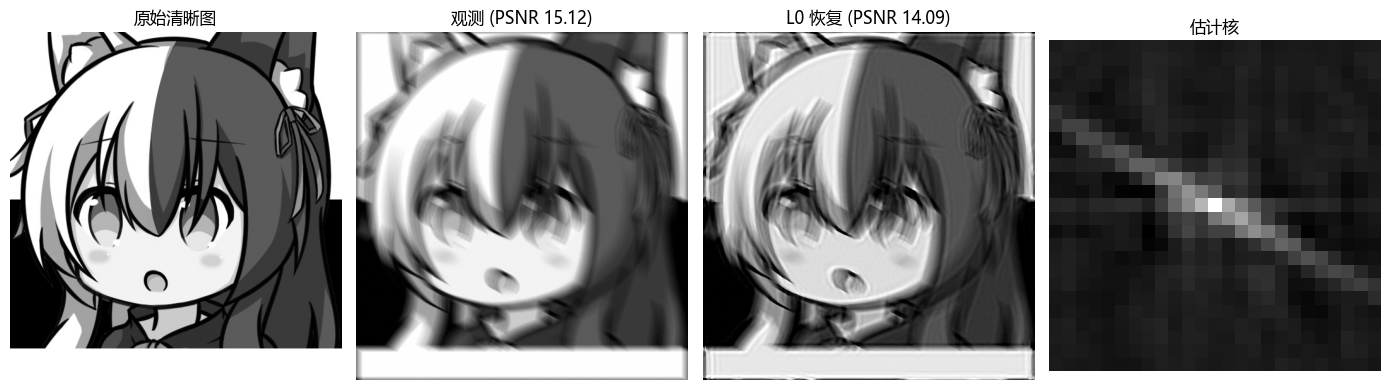

In [14]:
# 对比观测与重建结果
p_obs = compute_psnr(observed, gray)
s_obs = compute_ssim(observed, gray)
p_rec = compute_psnr(L, gray)
s_rec = compute_ssim(L, gray)
print(f'模糊+噪声观测 : PSNR = {p_obs:.2f} dB, SSIM = {s_obs:.4f}')
print(f'盲去卷积恢复 : PSNR = {p_rec:.2f} dB, SSIM = {s_rec:.4f}')

plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1); plt.imshow(gray, cmap='gray'); plt.title('原始清晰图'); plt.axis('off')
plt.subplot(1, 4, 2); plt.imshow(observed, cmap='gray'); plt.title(f'观测 (PSNR {p_obs:.2f})'); plt.axis('off')
plt.subplot(1, 4, 3); plt.imshow(L, cmap='gray'); plt.title(f'L0 恢复 (PSNR {p_rec:.2f})'); plt.axis('off')
plt.subplot(1, 4, 4); plt.imshow(k_est, cmap='gray'); plt.title('估计核'); plt.axis('off')
plt.tight_layout(); plt.show()
